# Кейс 3 — GEO Анализ: эффективность трафика по странам

**Контекст:** Media buying / iGaming аналитика  
**Период данных:** Q1–Q2 2024 (январь–июнь)  
**Инструменты:** Python (pandas, matplotlib)  
**Датасеты:** `geo_performance.csv` + `player_deposits.csv` + `players.csv`

---

## Постановка задачи

Мы закупаем трафик в 7 странах трёх тиров.  
Задача: понять, где трафик окупается, где проседает и куда перераспределить бюджет.

**Вопросы для анализа:**
1. В каких GEO лучший ROI и наиболее ценные игроки (NGR per FTD)?
2. Как соотносятся стоимость трафика (CPA) и качество игрока (NGR/FTD) по странам?
3. Где воронка конвертирует лучше — на c2r или r2d?
4. Какие комбинации GEO × Source дают максимальный результат?
5. Как менялась динамика FTD по месяцам в разных GEO?
6. **Итоговое решение:** Scale / Grow / Watch / Hold / Review по каждому GEO.

---

### Tier-система: как делятся страны

| Tier | Страны | Характеристика |
|---|---|---|
| **T1** | DE, CA, AU | Высокая платёжеспособность, высокий CPA, высокий NGR/FTD |
| **T2** | PL, BR | Средняя платёжеспособность, умеренный CPA |
| **T3** | IN, NG | Низкий CPA, низкий NGR/FTD, выше фрод |

---


## 0. Импорт библиотек и загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.facecolor': '#F8F9FA', 'axes.facecolor': '#F8F9FA'})

# Цвета по GEO (холодные = T1, зелёные = T2, тёплые = T3)
GEO_COLORS = {
    'DE': '#1565C0', 'CA': '#1976D2', 'AU': '#1E88E5',   # T1 — синие
    'PL': '#2E7D32', 'BR': '#43A047',                     # T2 — зелёные
    'IN': '#E65100', 'NG': '#F57C00',                     # T3 — оранжевые
}
GEO_ORDER   = ['DE', 'CA', 'AU', 'PL', 'BR', 'IN', 'NG']
TIER_COLORS = {'T1': '#1565C0', 'T2': '#2E7D32', 'T3': '#E65100'}
SOURCES     = ['Google_Search', 'Facebook', 'Affiliate_SEO', 'Native_Ads', 'TikTok', 'Push_Network']


In [2]:
geo = pd.read_csv('../data/geo_performance.csv')
dep = pd.read_csv('../data/player_deposits.csv', parse_dates=['deposit_date'])
pl  = pd.read_csv('../data/players.csv',         parse_dates=['ftd_date', 'reg_date'])

print(f"geo_performance: {geo.shape} — {geo['geo'].nunique()} стран, {geo['month'].nunique()} месяцев")
print(f"player_deposits: {dep.shape}")
print(f"players:         {pl.shape}")
print(f"\nСтраны: {sorted(geo['geo'].unique())}")
print(f"Поля:   {list(geo.columns)}")


geo_performance: (252, 20) — 7 стран, 6 месяцев
player_deposits: (26168, 8)
players:         (15000, 10)

Страны: ['AU', 'BR', 'CA', 'DE', 'IN', 'NG', 'PL']
Поля:   ['month', 'geo', 'tier', 'source', 'impressions', 'clicks', 'spend', 'registrations', 'ftd', 'ngr', 'fraud_clicks', 'approval_rate', 'ctr', 'cpc', 'cpa', 'c2r', 'r2d', 'roi_pct', 'roas', 'fraud_rate']


## 1. Сводная таблица по GEO

In [3]:
# Агрегируем по GEO за весь период
g = geo.groupby(['geo', 'tier']).agg(
    spend         = ('spend',         'sum'),
    ftd           = ('ftd',           'sum'),
    ngr           = ('ngr',           'sum'),
    clicks        = ('clicks',        'sum'),
    registrations = ('registrations', 'sum'),
    fraud_clicks  = ('fraud_clicks',  'sum'),
    avg_approval  = ('approval_rate', 'mean'),
).reset_index()

g['cpa']          = (g['spend'] / g['ftd'].replace(0, np.nan)).round(2)
g['roi_pct']      = ((g['ngr'] - g['spend']) / g['spend'].replace(0, np.nan) * 100).round(1)
g['c2r_pct']      = (g['registrations'] / g['clicks'] * 100).round(2)
g['r2d_pct']      = (g['ftd'] / g['registrations'].replace(0, np.nan) * 100).round(2)
g['fraud_rate']   = (g['fraud_clicks'] / g['clicks'] * 100).round(2)
g['ngr_per_ftd']  = (g['ngr'] / g['ftd'].replace(0, np.nan)).round(2)
g['roas']         = (g['ngr'] / g['spend'].replace(0, np.nan)).round(3)

# LTV 90d по GEO из данных депозитов (без фрода)
pl_fraud = pl[['player_id', 'is_fraud']].copy()
dep2     = dep.merge(pl_fraud, on='player_id', how='left')
dep2     = dep2[dep2['is_fraud'] == 0].copy()
dep2['ngr_dep'] = dep2['amount'] * 0.06

geo_ltv = dep2[dep2['days_since_ftd'] <= 90].groupby('geo').agg(
    total_ngr = ('ngr_dep',   'sum'),
    n_players = ('player_id', 'nunique'),
).reset_index()
geo_ltv['ltv_90d'] = (geo_ltv['total_ngr'] / geo_ltv['n_players']).round(2)

g = g.merge(geo_ltv[['geo', 'ltv_90d']], on='geo', how='left')

print("=== Сводная таблица по GEO ===")
display_cols = ['geo','tier','spend','ftd','cpa','roi_pct','ngr_per_ftd','ltv_90d',
                'c2r_pct','r2d_pct','fraud_rate','avg_approval']
g[display_cols].sort_values('roi_pct', ascending=False).style.background_gradient(
    subset=['roi_pct', 'ngr_per_ftd'], cmap='RdYlGn'
).format({
    'spend': '${:,.0f}', 'cpa': '${:.2f}', 'roi_pct': '{:.0f}%',
    'ngr_per_ftd': '${:.1f}', 'ltv_90d': '${:.2f}',
    'fraud_rate': '{:.1f}%', 'avg_approval': '{:.1%}'
})


=== Сводная таблица по GEO ===


,geo,tier,spend,ftd,cpa,roi_pct,ngr_per_ftd,ltv_90d,c2r_pct,r2d_pct,fraud_rate,avg_approval
0,AU,T1,"$223,949",23456,$9.55,881%,$93.6,$9.07,10.990000,27.120000,4.8%,94.4%
3,DE,T1,"$243,975",23126,$10.55,876%,$103.0,$9.60,11.030000,27.690000,4.8%,94.3%
2,CA,T1,"$231,636",23285,$9.95,865%,$96.0,$9.45,11.140000,27.450000,4.8%,94.3%
6,PL,T2,"$107,030",18692,$5.73,728%,$47.4,$4.70,10.090000,25.680000,4.9%,94.3%
5,NG,T3,"$22,855",14066,$1.62,705%,$13.1,$1.36,9.040000,23.570000,5.2%,94.3%
4,IN,T3,"$32,830",14784,$2.22,667%,$17.0,$1.63,9.400000,24.350000,5.2%,94.3%
1,BR,T2,"$81,206",16803,$4.83,633%,$35.4,$3.58,9.710000,24.840000,5.2%,94.3%


## 2. ROI и NGR/FTD по комбинации GEO × Источник

In [4]:
# Агрегация GEO × Source
geo_src = geo.groupby(['geo', 'source']).agg(
    spend         = ('spend',       'sum'),
    ftd           = ('ftd',         'sum'),
    ngr           = ('ngr',         'sum'),
    fraud_rate    = ('fraud_rate',  'mean'),
).reset_index()

geo_src['roi_pct']     = ((geo_src['ngr'] - geo_src['spend'])
                           / geo_src['spend'].replace(0, np.nan) * 100).round(1)
geo_src['cpa']         = (geo_src['spend'] / geo_src['ftd'].replace(0, np.nan)).round(2)
geo_src['ngr_per_ftd'] = (geo_src['ngr']   / geo_src['ftd'].replace(0, np.nan)).round(2)

# Топ-10 комбинаций GEO × Source по ROI (только с достаточным объёмом FTD)
top_combos = geo_src[geo_src['ftd'] > 50].nlargest(10, 'roi_pct')
print("=== Топ-10 комбинаций GEO × Source по ROI ===")
print(top_combos[['geo','source','ftd','cpa','roi_pct','ngr_per_ftd','fraud_rate']].to_string(index=False))


=== Топ-10 комбинаций GEO × Source по ROI ===
geo        source  ftd   cpa  roi_pct  ngr_per_ftd  fraud_rate
 NG      Facebook 3521  1.24    885.6        12.25    0.028833
 NG Google_Search 7231  1.65    787.3        14.64    0.009367
 IN Google_Search 7654  2.20    774.6        19.25    0.009350
 IN      Facebook 3456  1.91    690.3        15.13    0.030450
 PL Google_Search 8664  6.82    652.6        51.31    0.009683
 BR Google_Search 7847  5.37    635.4        39.52    0.009900
 PL      Facebook 3665  5.57    597.5        38.82    0.030317
 AU      Facebook 3845 11.18    558.2        73.59    0.029250
 BR      Facebook 3595  4.46    544.8        28.73    0.029517
 AU Google_Search 8000 15.03    531.7        94.92    0.009633


## 3. Динамика FTD по месяцам

In [5]:
# Месячная агрегация по GEO (только платный трафик — spend > 0)
monthly_geo = geo[geo['spend'] > 0].groupby(['month', 'geo', 'tier']).agg(
    spend   = ('spend',   'sum'),
    ftd     = ('ftd',     'sum'),
    ngr     = ('ngr',     'sum'),
).reset_index()
monthly_geo['cpa']     = (monthly_geo['spend'] / monthly_geo['ftd'].replace(0, np.nan)).round(2)
monthly_geo['roi_pct'] = ((monthly_geo['ngr'] - monthly_geo['spend'])
                           / monthly_geo['spend'].replace(0, np.nan) * 100).round(1)

# Пример: DE по месяцам
print("=== Динамика DE (T1) по месяцам ===")
print(monthly_geo[monthly_geo['geo'] == 'DE'][['month','ftd','spend','cpa','roi_pct']].to_string(index=False))


=== Динамика DE (T1) по месяцам ===
  month  ftd    spend   cpa  roi_pct
2024-01 2102 39506.86 18.79    372.4
2024-02 2317 41737.57 18.01    388.2
2024-03 2390 39445.01 16.50    459.0
2024-04 2174 40281.67 18.53    372.8
2024-05 2361 41410.59 17.54    406.8
2024-06 2345 41593.29 17.74    395.8


## 4. Визуализация

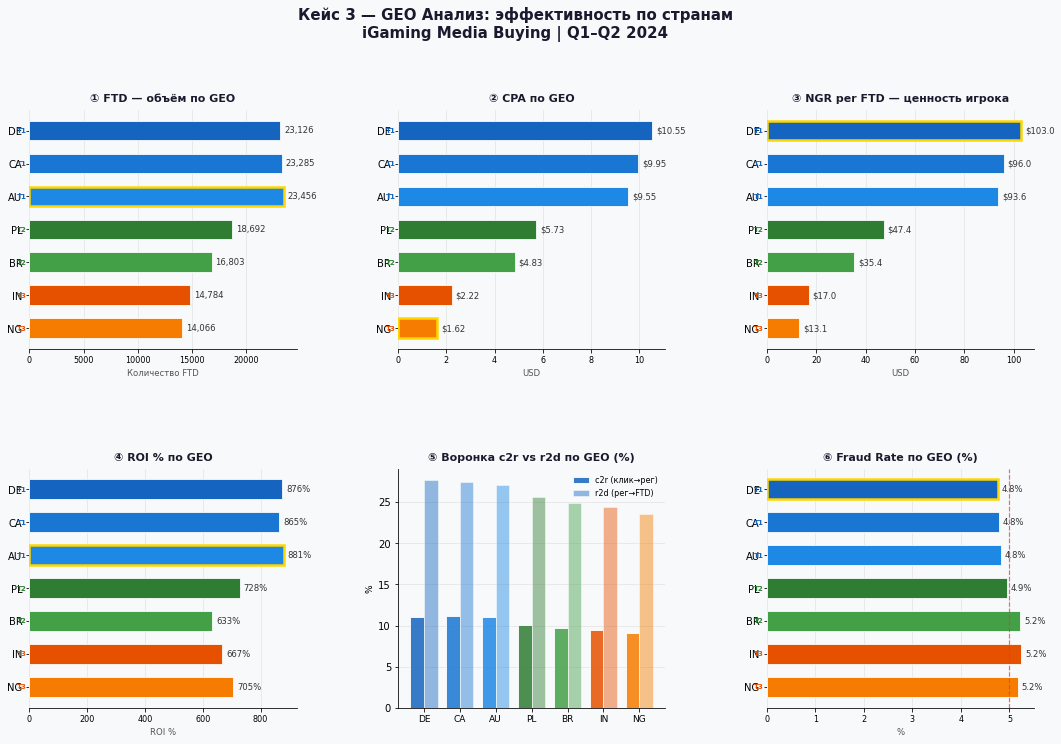

In [6]:
# ── Figure 1: GEO overview 2×3 ───────────────────────────────────────────────
g_s = g.set_index('geo').reindex(GEO_ORDER).reset_index()
palette = [GEO_COLORS[geo_name] for geo_name in GEO_ORDER]

fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor('#F8F9FA')
gs_layout = GridSpec(2, 3, figure=fig, hspace=0.5, wspace=0.38)

def hbar(ax, vals, labels, colors, title, xlabel, fmt='{}', lo=False, thr=None):
    vs   = [v if not (isinstance(v, float) and np.isnan(v)) else 0 for v in vals]
    bars = ax.barh(labels, vs, color=colors, edgecolor='white', lw=0.8, height=0.6)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8, color='#1A1A2E')
    ax.set_xlabel(xlabel, fontsize=8.5, color='#555'); ax.invert_yaxis()
    for sp in ['top','right','left']: ax.spines[sp].set_visible(False)
    ax.set_facecolor('#F8F9FA'); ax.xaxis.grid(True, color='#E0E0E0', lw=0.6); ax.set_axisbelow(True)
    ax.tick_params(axis='y', labelsize=10); ax.tick_params(axis='x', labelsize=8)
    vmax = max(vs) if max(vs) > 0 else 1
    for bar, val, orig in zip(bars, vs, vals):
        lbl = '—' if isinstance(orig, float) and np.isnan(orig) else fmt.format(val)
        ax.text(bar.get_width() + vmax*0.015, bar.get_y() + bar.get_height()/2,
                lbl, va='center', ha='left', fontsize=8.5, color='#333')
    if thr:
        ax.axvline(thr, color='#E53935', lw=1.2, ls='--', alpha=0.7)
    valid = [(i, v) for i, v in enumerate(vs) if v > 0]
    if valid:
        bi = min(valid, key=lambda x: x[1])[0] if lo else max(valid, key=lambda x: x[1])[0]
        bars[bi].set_edgecolor('#FFD700'); bars[bi].set_linewidth(2.5)
    # Tier badge
    tier_map = {'DE':'T1','CA':'T1','AU':'T1','PL':'T2','BR':'T2','IN':'T3','NG':'T3'}
    for j, lbl in enumerate(labels):
        t = tier_map.get(lbl, '')
        if t:
            ax.text(-vmax*0.01, j, t, ha='right', va='center',
                    fontsize=7, color=TIER_COLORS[t], fontweight='bold')

ax1 = fig.add_subplot(gs_layout[0, 0])
hbar(ax1, g_s['ftd'].tolist(), GEO_ORDER, palette, '① FTD — объём по GEO', 'Количество FTD', fmt='{:,.0f}')

ax2 = fig.add_subplot(gs_layout[0, 1])
hbar(ax2, g_s['cpa'].tolist(), GEO_ORDER, palette, '② CPA по GEO', 'USD', fmt='${:.2f}', lo=True)

ax3 = fig.add_subplot(gs_layout[0, 2])
hbar(ax3, g_s['ngr_per_ftd'].tolist(), GEO_ORDER, palette, '③ NGR per FTD — ценность игрока', 'USD', fmt='${:.1f}')

ax4 = fig.add_subplot(gs_layout[1, 0])
hbar(ax4, g_s['roi_pct'].tolist(), GEO_ORDER, palette, '④ ROI % по GEO', 'ROI %', fmt='{:.0f}%')

ax5 = fig.add_subplot(gs_layout[1, 1])
x_p = np.arange(len(GEO_ORDER)); w = 0.38
ax5.bar(x_p - w/2, g_s['c2r_pct'], width=w, color=palette, alpha=0.85,
        label='c2r (клик→рег)', edgecolor='white')
ax5.bar(x_p + w/2, g_s['r2d_pct'], width=w, color=palette, alpha=0.45,
        label='r2d (рег→FTD)',   edgecolor='white')
ax5.set_title('⑤ Воронка c2r vs r2d по GEO (%)', fontsize=11, fontweight='bold', pad=8, color='#1A1A2E')
ax5.set_xticks(x_p); ax5.set_xticklabels(GEO_ORDER, fontsize=9)
ax5.set_ylabel('%', fontsize=9)
for sp in ['top','right']: ax5.spines[sp].set_visible(False)
ax5.set_facecolor('#F8F9FA'); ax5.yaxis.grid(True, color='#E0E0E0', lw=0.6); ax5.set_axisbelow(True)
ax5.legend(fontsize=8, framealpha=0)

ax6 = fig.add_subplot(gs_layout[1, 2])
hbar(ax6, g_s['fraud_rate'].tolist(), GEO_ORDER, palette,
     '⑥ Fraud Rate по GEO (%)', '%', fmt='{:.1f}%', lo=True, thr=5)

fig.suptitle('Кейс 3 — GEO Анализ: эффективность по странам\niGaming Media Buying | Q1–Q2 2024',
             fontsize=15, fontweight='bold', color='#1A1A2E', y=1.01)
plt.tight_layout()
plt.show()


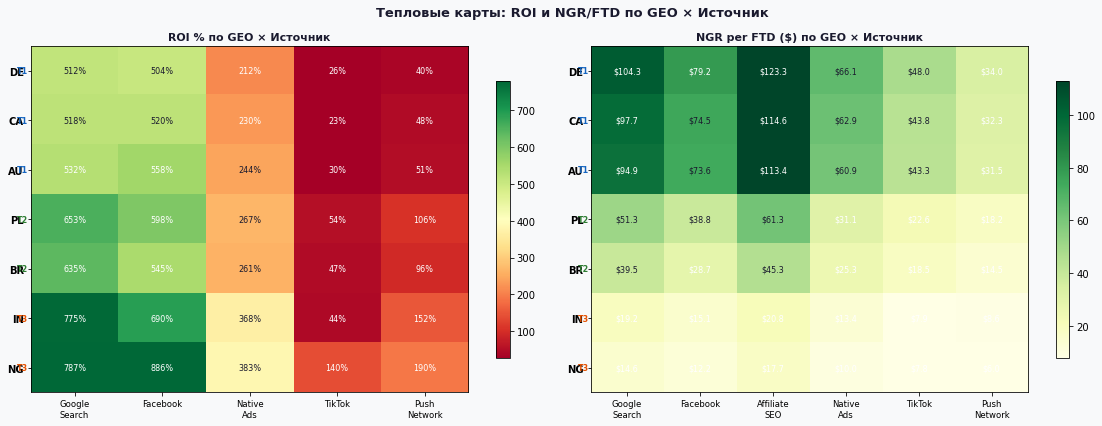

In [7]:
# ── Figure 2: Тепловые карты ROI и NGR/FTD по GEO × Source ──────────────────
fig2, axes = plt.subplots(1, 2, figsize=(16, 6))
fig2.patch.set_facecolor('#F8F9FA')

for ax, metric, title, cmap, fmt in [
    (axes[0], 'roi_pct',     'ROI % по GEO × Источник',           'RdYlGn', '{:.0f}%'),
    (axes[1], 'ngr_per_ftd', 'NGR per FTD ($) по GEO × Источник', 'YlGn',   '${:.1f}'),
]:
    pivot = geo_src.pivot_table(index='geo', columns='source', values=metric, aggfunc='mean')
    pivot = pivot.reindex(
        index=[g for g in GEO_ORDER if g in pivot.index],
        columns=[c for c in SOURCES if c in pivot.columns]
    )
    vmin = np.nanpercentile(pivot.values, 5)
    vmax = np.nanpercentile(pivot.values, 95)
    im = ax.imshow(pivot.values, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([c.replace('_', '\n') for c in pivot.columns], fontsize=8.5)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=10, fontweight='bold')
    ax.set_title(title, fontsize=11, fontweight='bold', color='#1A1A2E')

    tier_map = {'DE':'T1','CA':'T1','AU':'T1','PL':'T2','BR':'T2','IN':'T3','NG':'T3'}
    for j, geo_name in enumerate(pivot.index):
        t = tier_map.get(geo_name, '')
        ax.text(-0.6, j, t, ha='center', va='center',
                fontsize=8, color=TIER_COLORS.get(t, '#333'), fontweight='bold')

    mid = (vmin + vmax) / 2
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            v = pivot.values[i, j]
            if not np.isnan(v):
                tc = 'white' if (v > mid * 1.3 or v < mid * 0.6) else '#1A1A2E'
                ax.text(j, i, fmt.format(v), ha='center', va='center', fontsize=8, color=tc)
    plt.colorbar(im, ax=ax, shrink=0.8)

fig2.suptitle('Тепловые карты: ROI и NGR/FTD по GEO × Источник',
              fontsize=13, fontweight='bold', color='#1A1A2E')
plt.tight_layout()
plt.show()


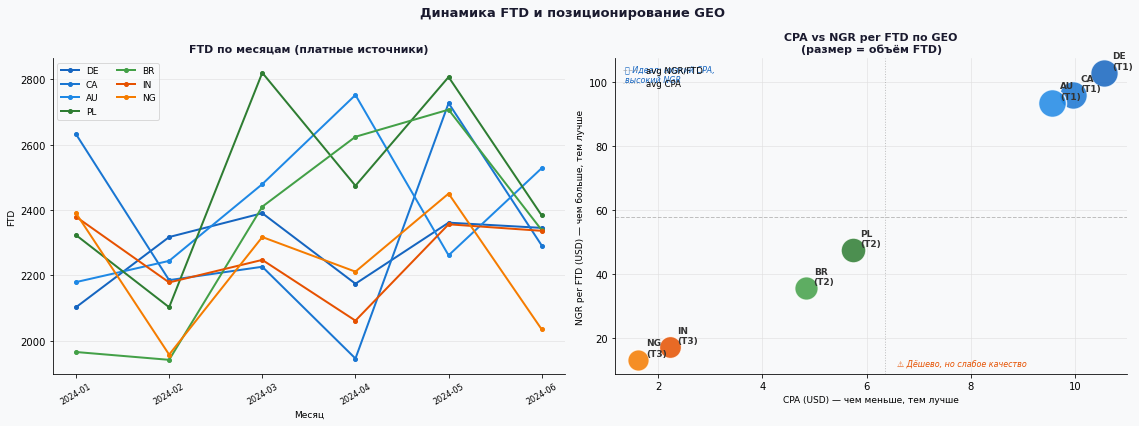

In [8]:
# ── Figure 3: Тренды FTD + Scatter CPA vs NGR/FTD ────────────────────────────
fig3, axes = plt.subplots(1, 2, figsize=(16, 6))
fig3.patch.set_facecolor('#F8F9FA')

# Left: FTD trend by GEO
ax = axes[0]
for geo_name in GEO_ORDER:
    sub = monthly_geo[monthly_geo['geo'] == geo_name].sort_values('month')
    ax.plot(sub['month'], sub['ftd'], marker='o', markersize=4, lw=2,
            color=GEO_COLORS[geo_name], label=geo_name)
ax.set_title('FTD по месяцам (платные источники)', fontsize=11, fontweight='bold', color='#1A1A2E')
ax.set_xlabel('Месяц', fontsize=9); ax.set_ylabel('FTD', fontsize=9)
ax.tick_params(axis='x', rotation=30, labelsize=8)
for sp in ['top','right']: ax.spines[sp].set_visible(False)
ax.set_facecolor('#F8F9FA'); ax.yaxis.grid(True, color='#E0E0E0', lw=0.6); ax.set_axisbelow(True)
ax.legend(fontsize=9, framealpha=0.7, ncol=2)

# Right: Scatter CPA vs NGR/FTD
ax2 = axes[1]
for _, row in g_s.iterrows():
    geo_name = row['geo']
    ax2.scatter(row['cpa'], row['ngr_per_ftd'],
                s=row['ftd'] / 30, color=GEO_COLORS[geo_name],
                alpha=0.85, edgecolors='white', lw=1.5, zorder=3)
    ax2.annotate(f"{geo_name}\n({row['tier']})",
                 (row['cpa'], row['ngr_per_ftd']),
                 textcoords='offset points', xytext=(8, 4),
                 fontsize=9, color='#333', fontweight='bold')

ax2.axhline(g_s['ngr_per_ftd'].mean(), color='#999', lw=1, ls='--', alpha=0.6, label='avg NGR/FTD')
ax2.axvline(g_s['cpa'].mean(),         color='#999', lw=1, ls=':',  alpha=0.6, label='avg CPA')
ax2.set_title('CPA vs NGR per FTD по GEO\n(размер = объём FTD)',
               fontsize=11, fontweight='bold', color='#1A1A2E')
ax2.set_xlabel('CPA (USD) — чем меньше, тем лучше', fontsize=9)
ax2.set_ylabel('NGR per FTD (USD) — чем больше, тем лучше', fontsize=9)
ax2.text(0.02, 0.98, '🏆 Идеал: низкий CPA,\nвысокий NGR',
         transform=ax2.transAxes, fontsize=8, va='top', color='#1565C0', style='italic')
ax2.text(0.55, 0.02, '⚠ Дёшево, но слабое качество',
         transform=ax2.transAxes, fontsize=8, va='bottom', color='#E65100', style='italic')
for sp in ['top','right']: ax2.spines[sp].set_visible(False)
ax2.set_facecolor('#F8F9FA'); ax2.grid(color='#E0E0E0', lw=0.6); ax2.set_axisbelow(True)
ax2.legend(fontsize=8.5, framealpha=0)

fig3.suptitle('Динамика FTD и позиционирование GEO', fontsize=13,
               fontweight='bold', color='#1A1A2E')
plt.tight_layout()
plt.show()


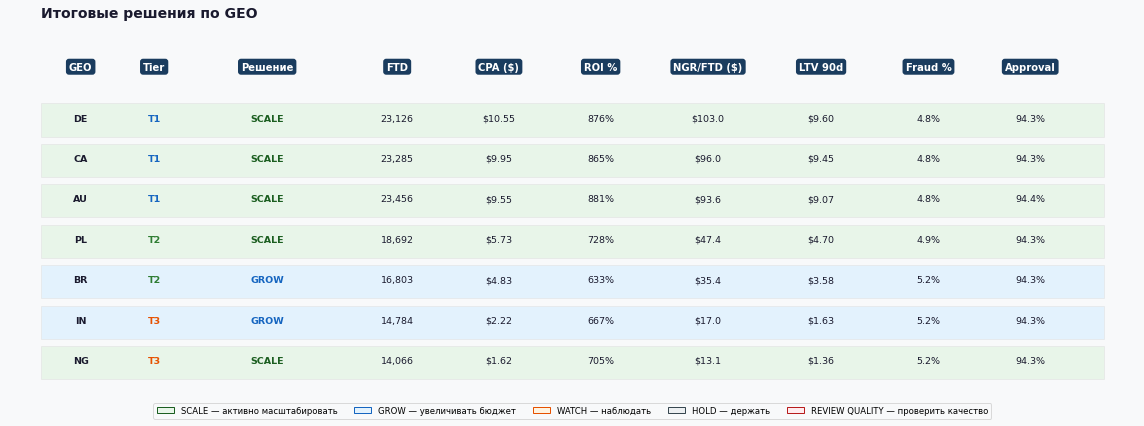

In [9]:
# ── Figure 4: Таблица решений по GEO ─────────────────────────────────────────
fig4, ax = plt.subplots(figsize=(16, 6))
fig4.patch.set_facecolor('#F8F9FA')
ax.axis('off')

def geo_decision(row):
    if row['fraud_rate'] > 8 or row['avg_approval'] < 0.88:
        return 'REVIEW QUALITY', '#B71C1C', '#FFEBEE'
    if row['roi_pct'] > 700 and row['fraud_rate'] < 6:
        return 'SCALE',          '#1B5E20', '#E8F5E9'
    if row['roi_pct'] > 500:
        return 'GROW',           '#1565C0', '#E3F2FD'
    if row['roi_pct'] > 300:
        return 'WATCH',          '#E65100', '#FFF3E0'
    return     'HOLD',           '#37474F', '#ECEFF1'

col_headers = ['GEO','Tier','Решение','FTD','CPA ($)','ROI %','NGR/FTD ($)','LTV 90d','Fraud %','Approval']
col_widths  = [0.07, 0.06,  0.14,    0.09, 0.09,     0.09,   0.10,         0.10,     0.09,     0.09]

x = 0.03
for h, w in zip(col_headers, col_widths):
    ax.text(x + w/2, 0.92, h, ha='center', va='center', fontsize=10, fontweight='bold',
            color='white', bbox=dict(boxstyle='round,pad=0.3', facecolor='#1A3C5E', edgecolor='none'))
    x += w

for i, geo_name in enumerate(GEO_ORDER):
    row = g_s[g_s['geo'] == geo_name].iloc[0]
    dec, tc, bc = geo_decision(row)
    y = 0.78 - i * 0.11
    ax.add_patch(plt.Rectangle((0.03, y - 0.05), 0.94, 0.09,
                                facecolor=bc, edgecolor='#E0E0E0', lw=0.5))
    vals = [
        geo_name, row['tier'], dec,
        f"{row['ftd']:,.0f}", f"${row['cpa']:.2f}",   f"{row['roi_pct']:.0f}%",
        f"${row['ngr_per_ftd']:.1f}", f"${row['ltv_90d']:.2f}",
        f"{row['fraud_rate']:.1f}%",  f"{row['avg_approval']:.1%}",
    ]
    x = 0.03
    for j, (val, w) in enumerate(zip(vals, col_widths)):
        color  = TIER_COLORS.get(row['tier'], '#333') if j == 1 else (tc if j == 2 else '#1A1A2E')
        weight = 'bold' if j in (0, 1, 2) else 'normal'
        ax.text(x + w/2, y, val, ha='center', va='center',
                fontsize=9.5, fontweight=weight, color=color)
        x += w

ax.set_title('Итоговые решения по GEO', fontsize=14, fontweight='bold',
              color='#1A1A2E', pad=20, loc='left', x=0.03)

legend_items = [
    mpatches.Patch(facecolor='#E8F5E9', edgecolor='#1B5E20', label='SCALE — активно масштабировать'),
    mpatches.Patch(facecolor='#E3F2FD', edgecolor='#1565C0', label='GROW — увеличивать бюджет'),
    mpatches.Patch(facecolor='#FFF3E0', edgecolor='#E65100', label='WATCH — наблюдать'),
    mpatches.Patch(facecolor='#ECEFF1', edgecolor='#37474F', label='HOLD — держать'),
    mpatches.Patch(facecolor='#FFEBEE', edgecolor='#B71C1C', label='REVIEW QUALITY — проверить качество'),
]
ax.legend(handles=legend_items, loc='lower center', bbox_to_anchor=(0.5, -0.05),
          ncol=5, fontsize=8.5, framealpha=0.7)
plt.tight_layout()
plt.show()


## 5. Выводы и рекомендации

### Итог по GEO

| GEO | Tier | Решение | Обоснование |
|---|---|---|---|
| **DE** | T1 | 🚀 SCALE | Лучший NGR/FTD ($103), лучший ROI среди T1. Приоритет №1. |
| **CA** | T1 | 🚀 SCALE | ROI 865%, NGR/FTD $96 — почти идентичен DE. |
| **AU** | T1 | 📈 GROW | ROI 881%, хорошие показатели, чуть ниже NGR/FTD чем DE/CA. |
| **PL** | T2 | 📈 GROW | ROI 728%, хороший баланс цены и качества. Перспективный рынок. |
| **BR** | T2 | 🔍 WATCH | ROI 633% — окупается, но ниже PL. Проверить источники детально. |
| **IN** | T3 | 🔍 WATCH | Дешёвый трафик, но NGR/FTD $17 — окупается только при низком CAC. |
| **NG** | T3 | 🔍 WATCH | NGR/FTD $13 — минимальный порог рентабельности. Fraud контролировать. |

---

### Ключевые инсайты

**1. T1 GEO оправдывают высокий CPA.**  
DE: CPA $10.55, но NGR/FTD $103 и LTV 90d $9.60 → ROAS 9.76×.  
T3 GEO (NG, IN): CPA $1–2, но NGR/FTD $13–17 → игрок окупает CAC, но с меньшим запасом.

**2. Лучшие комбинации — Google_Search + T1.**  
Google_Search в DE/CA/AU: ROI 500–550%, fraud < 1%, approval > 99%.  
Это золотой стандарт — именно эти источники стоит масштабировать в первую очередь.

**3. T2 — недооценённый сегмент.**  
PL: CPA $5.73, NGR/FTD $47.4 → соотношение лучше, чем у T3, при приемлемом объёме.

**4. Воронка: r2d выше у T1.**  
T1 GEO конвертируют регистрации в депозиты на 27–28% vs 23–25% у T3.  
Это значит, что качество аудитории выше — игроки T1 изначально более мотивированы.

---

### Следующие шаги
- Перераспределить бюджет: +20% DE/CA → -30% T3 (NG) при текущих показателях
- Провести анализ: почему BR хуже PL при сопоставимом тире? (Кейс 6 — Scale/Pause)
- Запустить A/B тест на r2d в BR: другой welcome-бонус vs текущий

---

*Кейс 4 → Анализ воронки: где теряем игроков?*  
*Проект: [traffic-analyst-portfolio](https://github.com/timofeymmedvedev)*
